# Gradient Boosting - Heart Disease

Explores a tuned Gradient Boosting classifier on the cleaned splits.

**Method.** Hyperparameters are tuned with stratified 5-fold `GridSearchCV` on the
**training** set; the tuned model is evaluated on the **validation** set. The
**test** set is deliberately left untouched here - it is reserved for the final
cross-model comparison notebook, so the hold-out is spent only once.

Gradient Boosting builds shallow trees sequentially, each one fit to the
residual errors of the ensemble so far. Like the other tree models it is
invariant to monotonic rescaling - no scaler is added to the pipeline.

In [1]:
import sys
from pathlib import Path

# Make the scripts/ helpers importable from notebooks/.
sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score, f1_score, accuracy_score,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay,
)

from dataset import load_splits, get_xy
from train_models import build_pipeline, MODELS, CV

MODEL_NAME = "gradient_boosting"

## Load data

In [2]:
train, val, test = load_splits()
X_train, y_train = get_xy(train)
X_val, y_val = get_xy(val)

print(f"train {X_train.shape}  val {X_val.shape}  (test held back)")
print(f"train disease rate {y_train.mean():.3f}  val {y_val.mean():.3f}")

train (552, 15)  val (184, 15)  (test held back)
train disease rate 0.553  val 0.554


## Tune hyperparameters (train, 5-fold CV)

The estimator and grid come straight from the `MODELS` registry in
`train_models.py`, so the notebook and the batch script stay in sync.

In [3]:
cfg = MODELS[MODEL_NAME]
pipe = build_pipeline(cfg["estimator"], cfg["needs_scaling"], list(X_train.columns))
search = GridSearchCV(pipe, cfg["grid"], cv=CV, scoring="roc_auc", n_jobs=-1)
search.fit(X_train, y_train)

best = search.best_estimator_
print("best params:", search.best_params_)
print(f"cv roc-auc: {search.best_score_:.3f}")

best params: {'model__learning_rate': 0.01, 'model__max_depth': 2, 'model__n_estimators': 300}
cv roc-auc: 0.861


## Validation metrics

In [4]:
proba = best.predict_proba(X_val)[:, 1]
pred = best.predict(X_val)

metrics = {
    "roc_auc": roc_auc_score(y_val, proba),
    "recall": recall_score(y_val, pred),
    "precision": precision_score(y_val, pred),
    "f1": f1_score(y_val, pred),
    "accuracy": accuracy_score(y_val, pred),
}
pd.Series(metrics, name=MODEL_NAME).round(3)

roc_auc      0.856
recall       0.873
precision    0.767
f1           0.817
accuracy     0.783
Name: gradient_boosting, dtype: float64

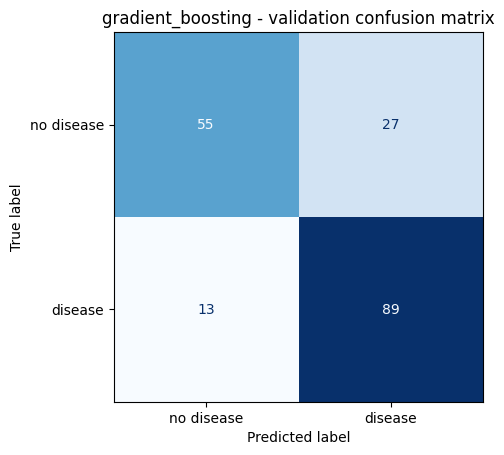

In [ ]:
ConfusionMatrixDisplay(
    confusion_matrix(y_val, pred), display_labels=["no disease", "disease"]
).plot(cmap="Blues", colorbar=False)
plt.title(f"{MODEL_NAME} - validation confusion matrix")
plt.show()

## Hyperparameter comparison

`n_estimators` and `learning_rate` trade off against each other (more, smaller
steps vs fewer, larger ones), while `max_depth` sets how much interaction each
tree can capture. The full grid is small enough to show every configuration.

In [ ]:
cv_results = pd.DataFrame(search.cv_results_)
param_cols = ["param_model__n_estimators", "param_model__learning_rate", "param_model__max_depth"]

gb_grid = cv_results[param_cols + ["mean_test_score", "std_test_score"]].copy()
gb_grid = gb_grid.rename(columns={
    "param_model__n_estimators": "n_estimators",
    "param_model__learning_rate": "learning_rate",
    "param_model__max_depth": "max_depth",
    "mean_test_score": "cv_roc_auc",
    "std_test_score": "cv_std",
})
gb_grid.sort_values("cv_roc_auc", ascending=False).round(3)

,n_estimators,learning_rate,max_depth,cv_roc_auc,cv_std
1,300,0.01,2,0.861,0.037
3,300,0.01,3,0.856,0.033
4,100,0.10,2,0.852,0.043
0,100,0.01,2,0.848,0.023
6,100,0.10,3,0.847,0.032
2,100,0.01,3,0.840,0.033
5,300,0.10,2,0.836,0.036
7,300,0.10,3,0.831,0.024


## Staged performance

Boosting adds one tree per stage, so the tuned model can be scored after every
stage with `staged_predict_proba`. Training ROC-AUC climbs steadily toward 1.0
as the ensemble memorizes the training set; the validation curve shows where
the extra stages stop paying for themselves.

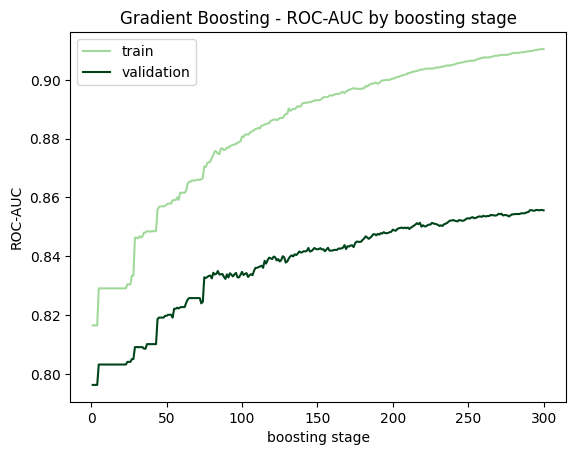

In [ ]:
gb = best.named_steps["model"]

stage_auc_train = [roc_auc_score(y_train, p[:, 1]) for p in gb.staged_predict_proba(X_train)]
stage_auc_val = [roc_auc_score(y_val, p[:, 1]) for p in gb.staged_predict_proba(X_val)]
stages = range(1, len(stage_auc_val) + 1)

plt.plot(stages, stage_auc_train, color="#a1d99b", label="train")
plt.plot(stages, stage_auc_val, color="#00441b", label="validation")
plt.xlabel("boosting stage")
plt.ylabel("ROC-AUC")
plt.title("Gradient Boosting - ROC-AUC by boosting stage")
plt.legend()
plt.show()

## Feature importance

Impurity importances summed over every tree in the ensemble. As with the other
tree models they are biased toward continuous features with many split points.

Caveat: ~22% of `chol` is iteratively imputed with low-variance synthetic
values (see PROJECT.md), so read its importance with that in mind.

In [ ]:
importance = pd.Series(gb.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False).round(3)

cp_4         0.352
age          0.146
exang        0.121
sex          0.109
oldpeak      0.095
thalach      0.090
chol         0.035
cp_2         0.033
trestbps     0.010
fbs          0.006
restecg_1    0.002
restecg_0    0.000
cp_1         0.000
cp_3         0.000
restecg_2    0.000
dtype: float64

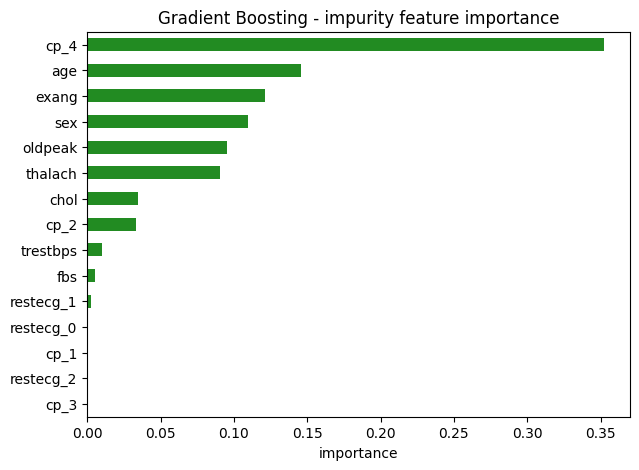

In [ ]:
importance.sort_values().plot(kind="barh", color="forestgreen", figsize=(7, 5))
plt.xlabel("importance")
plt.title("Gradient Boosting - impurity feature importance")
plt.show()

## ROC curve (validation)

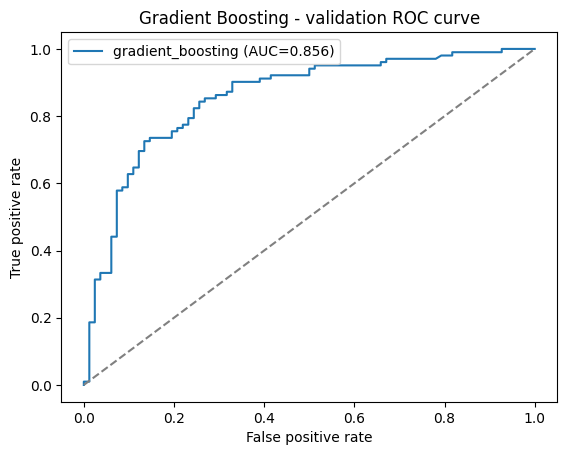

In [ ]:
fpr, tpr, _ = roc_curve(y_val, proba)
plt.plot(fpr, tpr, label=f"{MODEL_NAME} (AUC={metrics['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], ls="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Gradient Boosting - validation ROC curve")
plt.legend()
plt.show()

## Notes

- Test set intentionally not touched - see the comparison notebook for the
  single final test evaluation of the selected model.
- The staged curve evaluates intermediate ensembles of the already-tuned
  model; it is a diagnostic, not a second tuning pass.
- This notebook is Gradient Boosting specific. To explore another model, start
  from the shared template and swap in a model-appropriate diagnostic.